In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../concatenacao/dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')

/tmp/ipykernel_2017/3667309216.py:1: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('concatenacao/dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91964 entries, 0 to 91963
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   titulo                  91964 non-null  object 
 1   nome_orientador         77906 non-null  object 
 2   nivel                   91964 non-null  object 
 3   ano                     91964 non-null  float64
 4   classificacao           91964 non-null  object 
 5   unidade                 91624 non-null  object 
 6   palavras_chave          13836 non-null  object 
 7   data_inicio             91961 non-null  object 
 8   data_fim                91733 non-null  object 
 9   situacao                91964 non-null  object 
 10  tipo_projeto            91964 non-null  object 
 11  linha_pesquisa          13611 non-null  object 
 12  area_conhecimento_cnpq  13744 non-null  object 
 13  categoria               74254 non-null  object 
dtypes: float64(1), object(13)
memory usage

In [13]:
# Glossário:
# - título: titulo do projeto
# - nome_orientador: nome do orientador do projeto (apenas em tccs)
# - nivel: nivel acadêmico (graduação, mestrado, etc)
# - ano: ano de relevância do projeto
# - classificação: se é tcc ou pesquisa
# - unidade: unidade acadêmica responsável pelo projeto
# - palavras_chave: palavras chaves do projeto
# - data_inicio: data de inicio do projeto
# - data_fim: data de finalização do projeto
# - situacao: situação de andamento do projeto (finalizado, em andamento, etc)
# - tipo_projeto: interno ou externo
# - linha_pesquisa: linha de pesquisa (somente projetos de pesquisa)
# - categoria: categoria do projeto (se é monografia, artigo, pesquisa, seminário, etc)

In [14]:
df['data_inicio'] = pd.to_datetime(df['data_inicio'], errors='coerce')
df['data_fim'] = pd.to_datetime(df['data_fim'], errors='coerce')


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91964 entries, 0 to 91963
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   titulo                  91964 non-null  object        
 1   nome_orientador         77906 non-null  object        
 2   nivel                   91964 non-null  object        
 3   ano                     91964 non-null  float64       
 4   classificacao           91964 non-null  object        
 5   unidade                 91624 non-null  object        
 6   palavras_chave          13836 non-null  object        
 7   data_inicio             77905 non-null  datetime64[ns]
 8   data_fim                77905 non-null  datetime64[ns]
 9   situacao                91964 non-null  object        
 10  tipo_projeto            91964 non-null  object        
 11  linha_pesquisa          13611 non-null  object        
 12  area_conhecimento_cnpq  13744 non-null  object

In [16]:
# Evolução de projetos por ano
projetos_por_ano = df.groupby('ano').size()

# Sazonalidade de início de projetos
df['mes_inicio'] = df['data_inicio'].dt.month
projetos_por_mes = df.groupby('mes_inicio').size()

# Duração média dos projetos
df['duracao'] = df['data_fim'] - df['data_inicio']

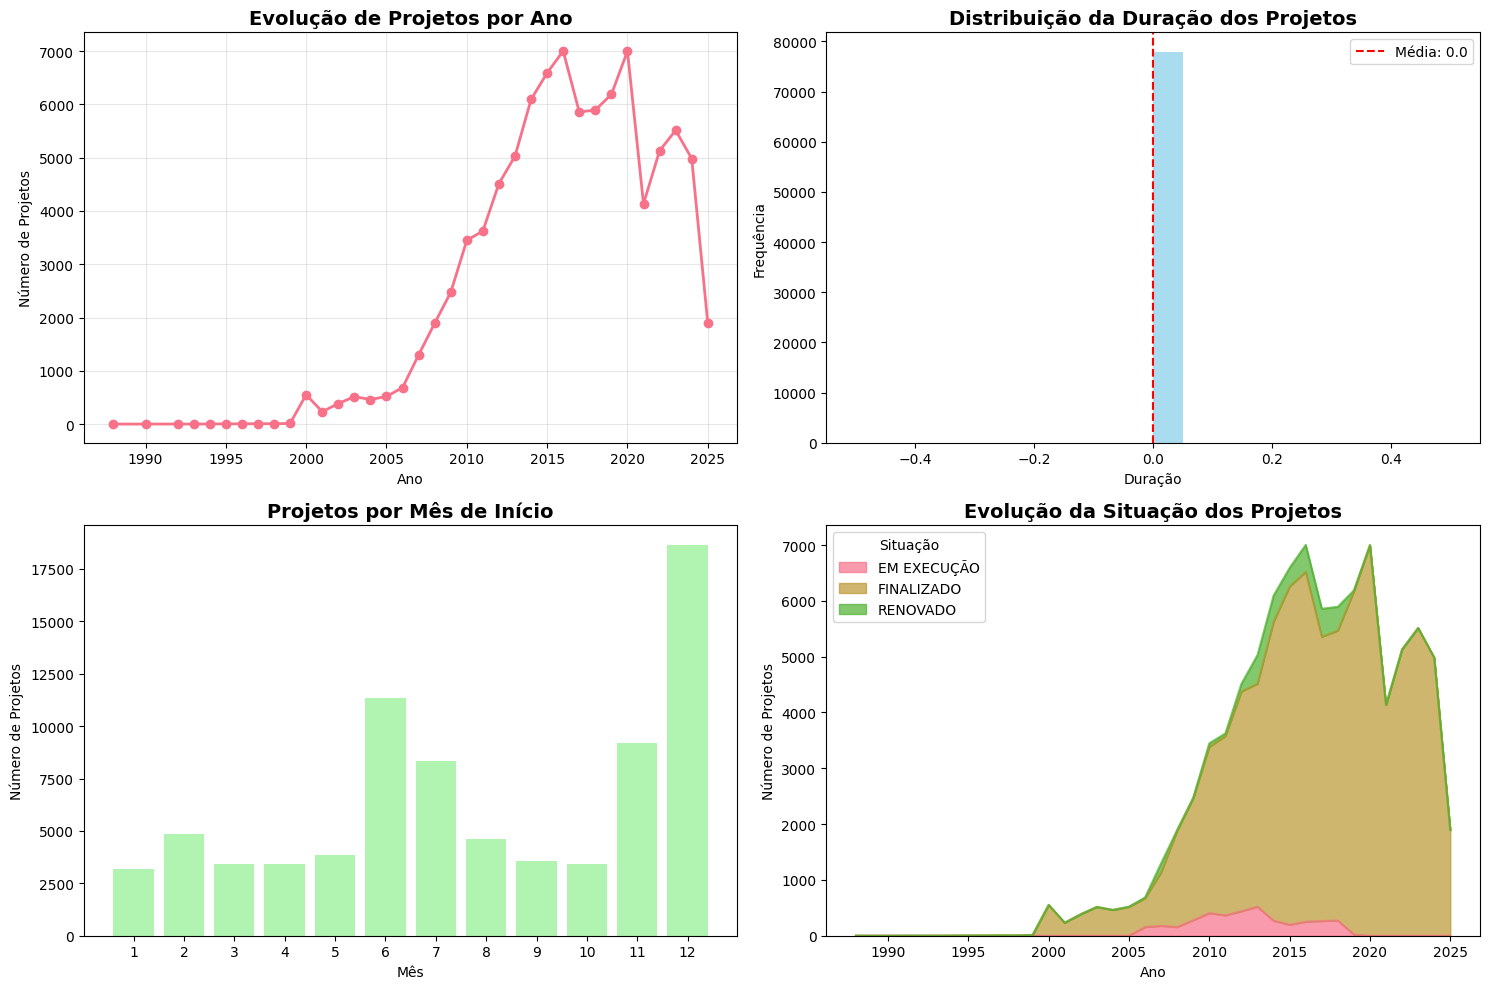

In [17]:
# Configuração do estilo
plt.style.use('default')
sns.set_palette("husl")

# Gráfico 1: Análise Temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Projetos por ano
if 'ano' in df.columns:
    projetos_por_ano = df.groupby('ano').size()
    axes[0,0].plot(projetos_por_ano.index, projetos_por_ano.values, marker='o', linewidth=2)
    axes[0,0].set_title('Evolução de Projetos por Ano', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Ano')
    axes[0,0].set_ylabel('Número de Projetos')
    axes[0,0].grid(True, alpha=0.3)
else:
    axes[0,0].text(0.5, 0.5, 'Coluna "ano" não encontrada', 
                   ha='center', va='center', transform=axes[0,0].transAxes)
    axes[0,0].set_title('Evolução de Projetos por Ano', fontsize=14, fontweight='bold')

# Duração dos projetos (usando coluna existente)
if 'duracao' in df.columns:
    # Converter para numérico se necessário e filtrar valores válidos
    duracao_valida = pd.to_numeric(df['duracao'], errors='coerce').dropna()
    duracao_valida = duracao_valida[duracao_valida >= 0]
    
    if not duracao_valida.empty:
        axes[0,1].hist(duracao_valida, bins=20, alpha=0.7, color='skyblue')
        axes[0,1].set_title('Distribuição da Duração dos Projetos', fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Duração')
        axes[0,1].set_ylabel('Frequência')
        
        # Adicionar estatísticas no gráfico
        media_duracao = duracao_valida.mean()
        axes[0,1].axvline(media_duracao, color='red', linestyle='--', label=f'Média: {media_duracao:.1f}')
        axes[0,1].legend()
    else:
        axes[0,1].text(0.5, 0.5, 'Dados de duração não disponíveis', 
                       ha='center', va='center', transform=axes[0,1].transAxes)
        axes[0,1].set_title('Distribuição da Duração', fontsize=14, fontweight='bold')
else:
    axes[0,1].text(0.5, 0.5, 'Coluna "duracao" não encontrada', 
                   ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Distribuição da Duração', fontsize=14, fontweight='bold')

# Mês de início dos projetos
if 'data_inicio' in df.columns:
    df['mes_inicio'] = df['data_inicio'].dt.month
    projetos_por_mes = df['mes_inicio'].value_counts().sort_index()
    axes[1,0].bar(projetos_por_mes.index, projetos_por_mes.values, alpha=0.7, color='lightgreen')
    axes[1,0].set_title('Projetos por Mês de Início', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Mês')
    axes[1,0].set_ylabel('Número de Projetos')
    axes[1,0].set_xticks(range(1, 13))
else:
    axes[1,0].text(0.5, 0.5, 'Coluna "data_inicio" não encontrada', 
                   ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Projetos por Mês de Início', fontsize=14, fontweight='bold')

# Situação ao longo dos anos
if 'ano' in df.columns and 'situacao' in df.columns:
    situacao_por_ano = pd.crosstab(df['ano'], df['situacao'])
    situacao_por_ano.plot(kind='area', ax=axes[1,1], alpha=0.7)
    axes[1,1].set_title('Evolução da Situação dos Projetos', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Ano')
    axes[1,1].set_ylabel('Número de Projetos')
    axes[1,1].legend(title='Situação')
else:
    axes[1,1].text(0.5, 0.5, 'Dados insuficientes', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Evolução da Situação', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

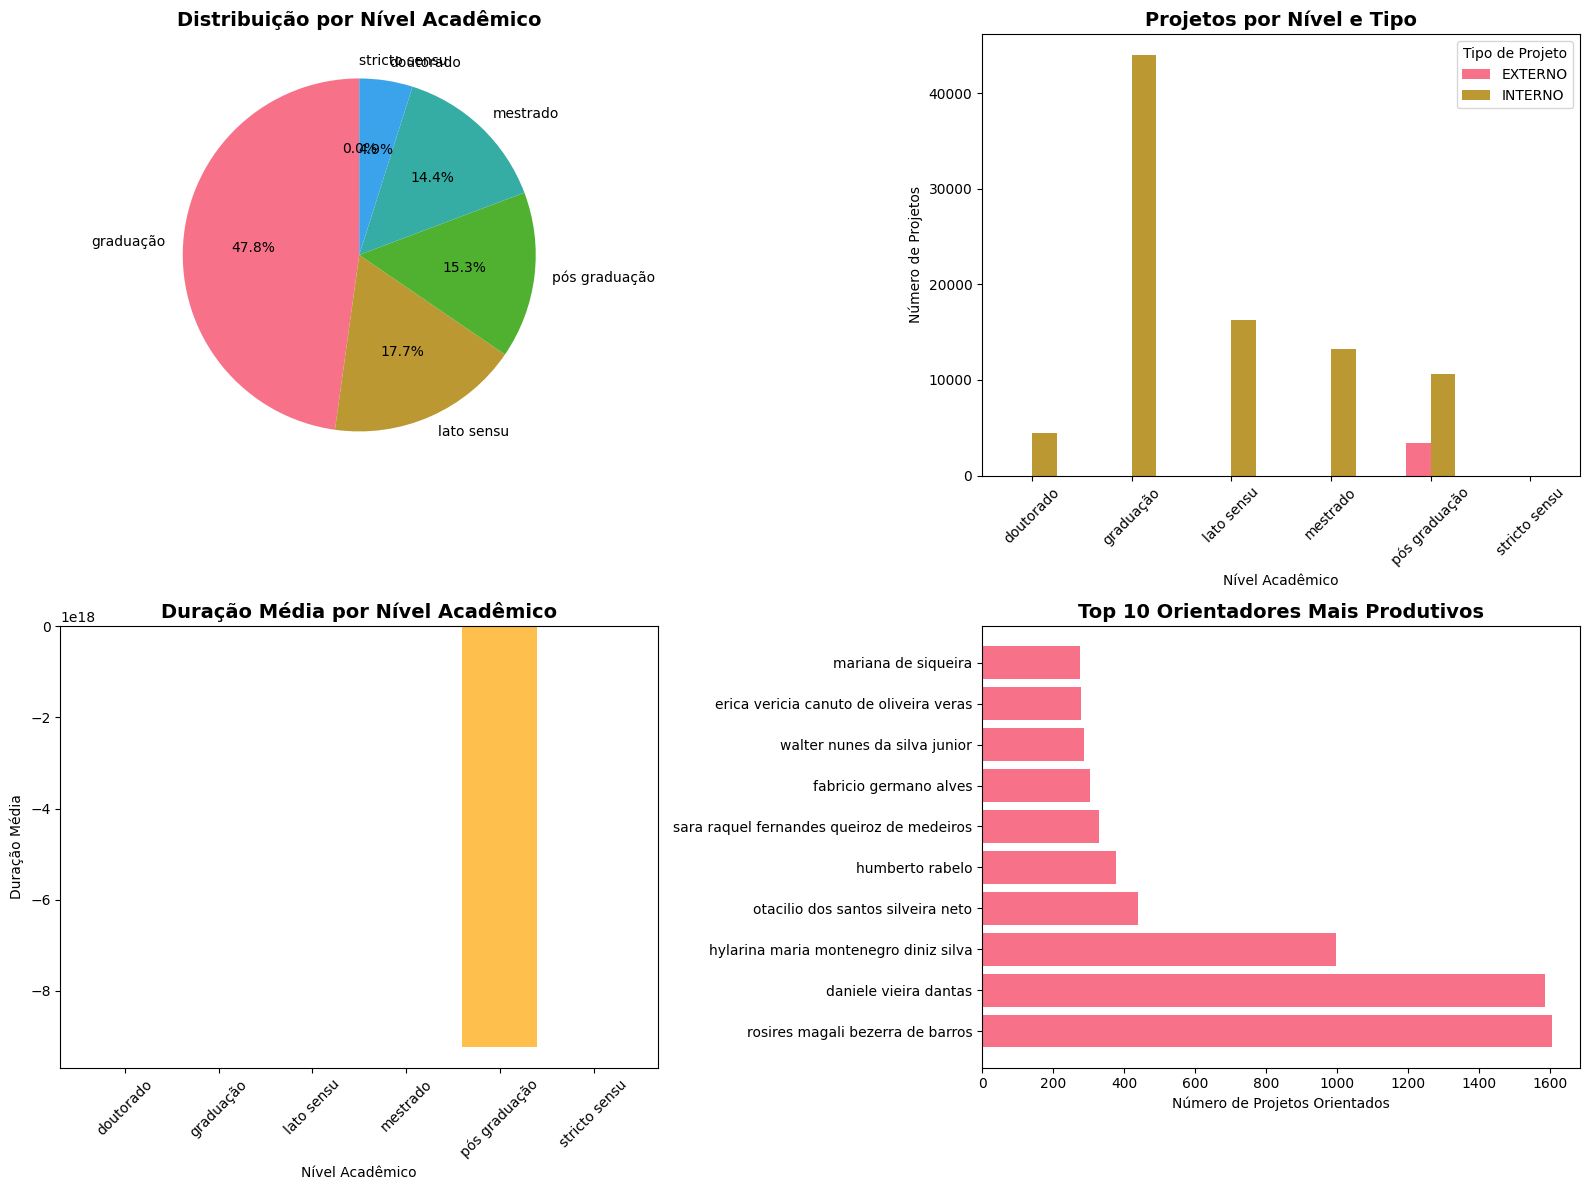

In [18]:
# Gráfico 2: Distribuição por nível e tipo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribuição por nível acadêmico
if 'nivel' in df.columns:
    distribuicao_nivel = df['nivel'].value_counts()
    axes[0,0].pie(distribuicao_nivel.values, labels=distribuicao_nivel.index, autopct='%1.1f%%', startangle=90)
    axes[0,0].set_title('Distribuição por Nível Acadêmico', fontsize=14, fontweight='bold')
else:
    axes[0,0].text(0.5, 0.5, 'Coluna "nivel" não encontrada', 
                   ha='center', va='center', transform=axes[0,0].transAxes)
    axes[0,0].set_title('Distribuição por Nível Acadêmico', fontsize=14, fontweight='bold')

# Relação nível vs tipo de projeto
if 'nivel' in df.columns and 'tipo_projeto' in df.columns:
    cross_nivel_tipo = pd.crosstab(df['nivel'], df['tipo_projeto'])
    cross_nivel_tipo.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Projetos por Nível e Tipo', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Nível Acadêmico')
    axes[0,1].set_ylabel('Número de Projetos')
    axes[0,1].legend(title='Tipo de Projeto')
    axes[0,1].tick_params(axis='x', rotation=45)
else:
    axes[0,1].text(0.5, 0.5, 'Dados insuficientes', 
                   ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Projetos por Nível e Tipo', fontsize=14, fontweight='bold')

# Duração média por nível
if 'nivel' in df.columns and 'duracao' in df.columns:
    duracao_por_nivel = df.groupby('nivel')['duracao'].mean()
    if not duracao_por_nivel.empty:
        axes[1,0].bar(duracao_por_nivel.index, duracao_por_nivel.values, color='orange', alpha=0.7)
        axes[1,0].set_title('Duração Média por Nível Acadêmico', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Nível Acadêmico')
        axes[1,0].set_ylabel('Duração Média')
        axes[1,0].tick_params(axis='x', rotation=45)
    else:
        axes[1,0].text(0.5, 0.5, 'Sem dados de duração', 
                       ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Duração Média por Nível', fontsize=14, fontweight='bold')
else:
    axes[1,0].text(0.5, 0.5, 'Dados insuficientes', 
                   ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Duração Média por Nível', fontsize=14, fontweight='bold')

# Orientadores mais produtivos
if 'nome_orientador' in df.columns:
    orientadores_top = df['nome_orientador'].value_counts().head(10)
    if not orientadores_top.empty:
        axes[1,1].barh(range(len(orientadores_top)), orientadores_top.values)
        axes[1,1].set_yticks(range(len(orientadores_top)))
        axes[1,1].set_yticklabels(orientadores_top.index)
        axes[1,1].set_title('Top 10 Orientadores Mais Produtivos', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Número de Projetos Orientados')
    else:
        axes[1,1].text(0.5, 0.5, 'Sem dados de orientadores', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Top 10 Orientadores', fontsize=14, fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'Coluna "nome_orientador" não encontrada', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Top 10 Orientadores', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

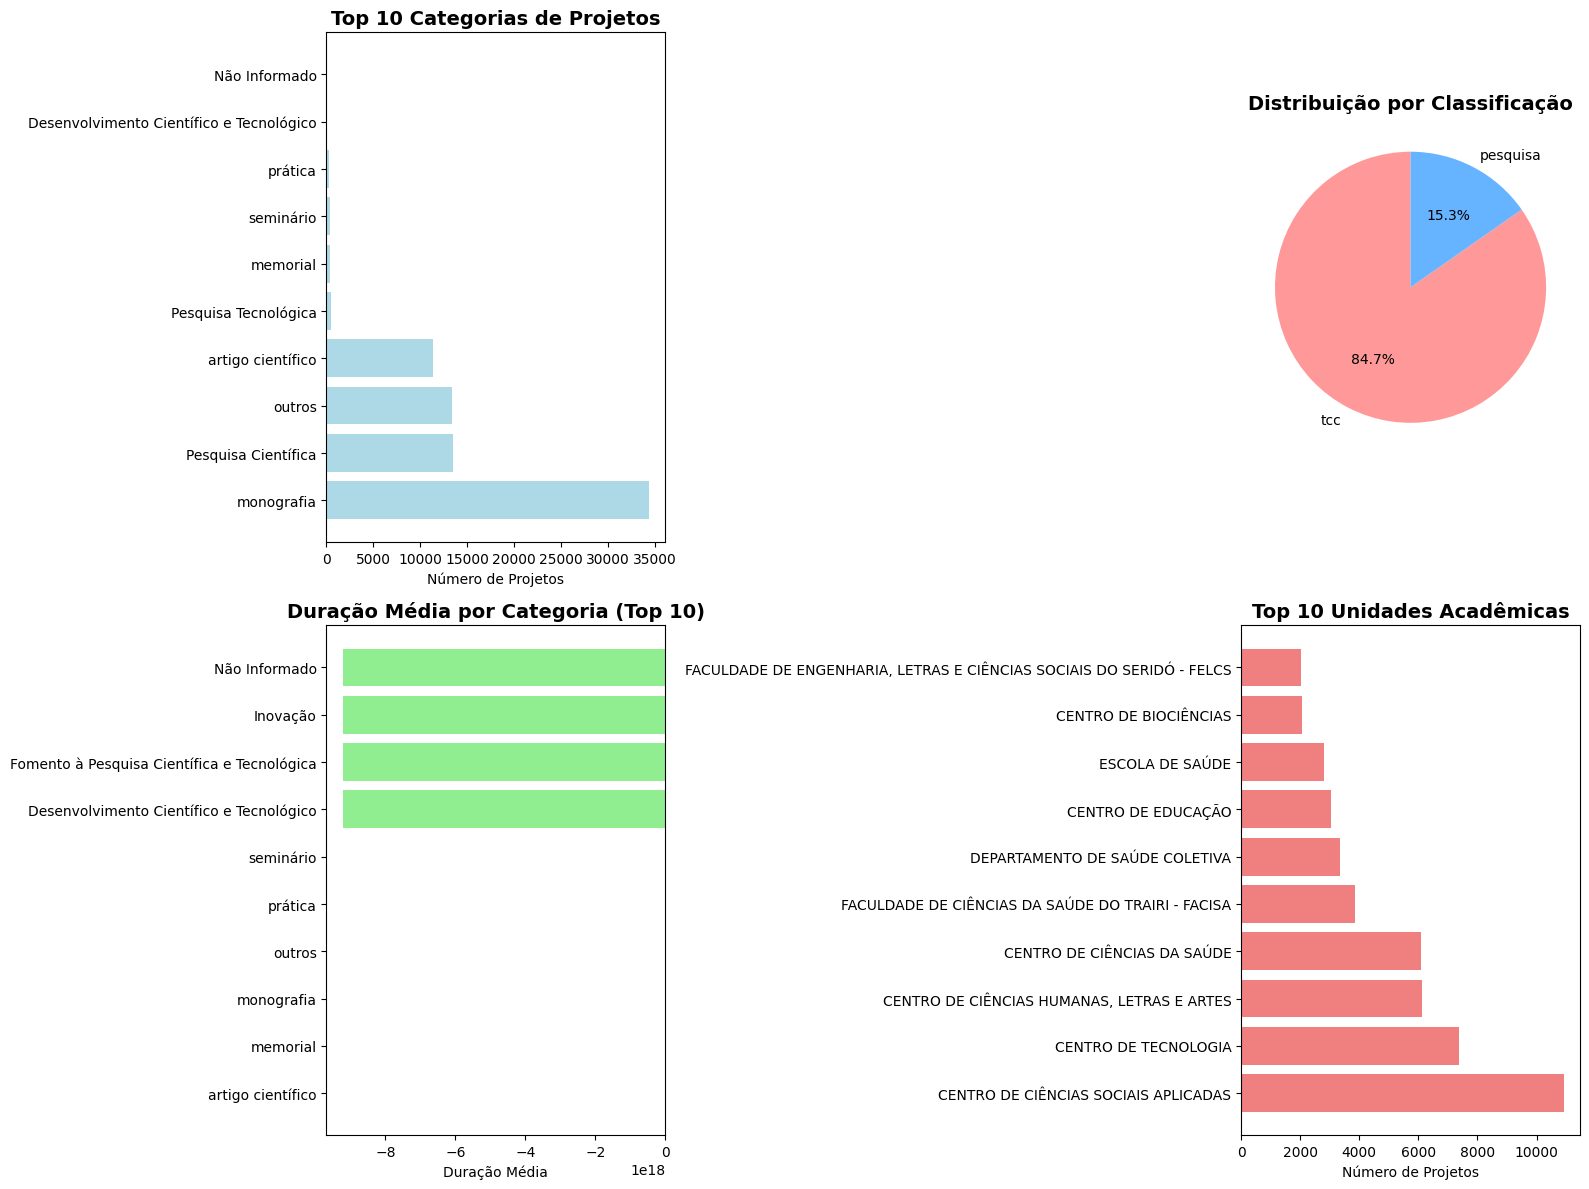

In [19]:
# Gráfico 3: Categorias e classificações
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribuição de categorias (top 10)
if 'categoria' in df.columns:
    top_categorias = df['categoria'].value_counts().head(10)
    if not top_categorias.empty:
        axes[0,0].barh(range(len(top_categorias)), top_categorias.values, color='lightblue')
        axes[0,0].set_yticks(range(len(top_categorias)))
        axes[0,0].set_yticklabels(top_categorias.index)
        axes[0,0].set_title('Top 10 Categorias de Projetos', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Número de Projetos')
    else:
        axes[0,0].text(0.5, 0.5, 'Sem dados de categoria', 
                       ha='center', va='center', transform=axes[0,0].transAxes)
        axes[0,0].set_title('Top 10 Categorias', fontsize=14, fontweight='bold')
else:
    axes[0,0].text(0.5, 0.5, 'Coluna "categoria" não encontrada', 
                   ha='center', va='center', transform=axes[0,0].transAxes)
    axes[0,0].set_title('Top 10 Categorias', fontsize=14, fontweight='bold')

# Classificação dos projetos
if 'classificacao' in df.columns:
    classificacao = df['classificacao'].value_counts()
    axes[0,1].pie(classificacao.values, labels=classificacao.index, autopct='%1.1f%%', 
                  startangle=90, colors=['#ff9999', '#66b3ff'])
    axes[0,1].set_title('Distribuição por Classificação', fontsize=14, fontweight='bold')
else:
    axes[0,1].text(0.5, 0.5, 'Coluna "classificação" não encontrada', 
                   ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Distribuição por Classificação', fontsize=14, fontweight='bold')

# Duração média por categoria
if 'categoria' in df.columns and 'duracao' in df.columns:
    duracao_por_categoria = df.groupby('categoria')['duracao'].mean().sort_values(ascending=False).head(10)
    if not duracao_por_categoria.empty:
        axes[1,0].barh(range(len(duracao_por_categoria)), duracao_por_categoria.values, color='lightgreen')
        axes[1,0].set_yticks(range(len(duracao_por_categoria)))
        axes[1,0].set_yticklabels(duracao_por_categoria.index)
        axes[1,0].set_title('Duração Média por Categoria (Top 10)', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Duração Média')
    else:
        axes[1,0].text(0.5, 0.5, 'Sem dados para cálculo', 
                       ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Duração Média por Categoria', fontsize=14, fontweight='bold')
else:
    axes[1,0].text(0.5, 0.5, 'Dados insuficientes', 
                   ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Duração Média por Categoria', fontsize=14, fontweight='bold')

# Projetos por unidade (top 10)
if 'unidade' in df.columns:
    top_unidades = df['unidade'].value_counts().head(10)
    if not top_unidades.empty:
        axes[1,1].barh(range(len(top_unidades)), top_unidades.values, color='lightcoral')
        axes[1,1].set_yticks(range(len(top_unidades)))
        axes[1,1].set_yticklabels(top_unidades.index)
        axes[1,1].set_title('Top 10 Unidades Acadêmicas', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Número de Projetos')
    else:
        axes[1,1].text(0.5, 0.5, 'Sem dados de unidade', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Top 10 Unidades', fontsize=14, fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'Coluna "unidade" não encontrada', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Top 10 Unidades', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

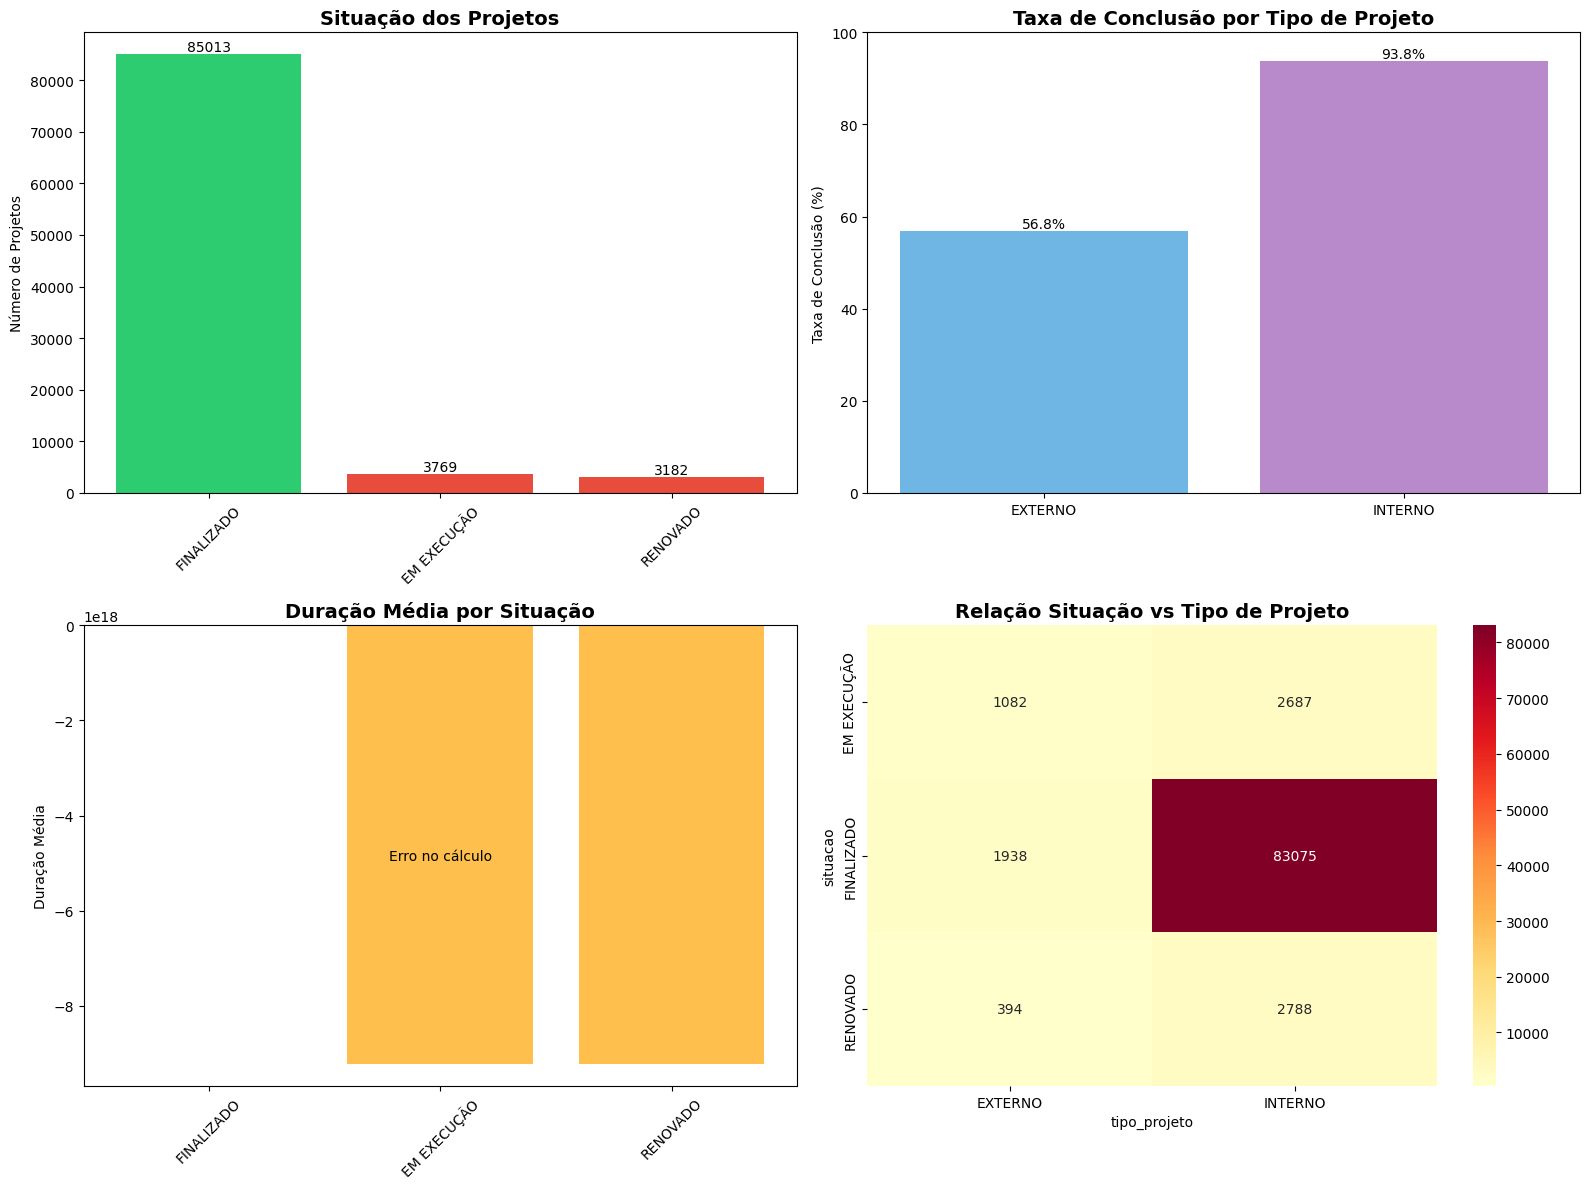

In [20]:
# Gráfico 4: Situação dos projetos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Situação dos projetos
if 'situacao' in df.columns:
    situacao_projetos = df['situacao'].value_counts()
    if not situacao_projetos.empty:
        colors = ['#2ecc71' if 'finalizado' in str(x).lower() else 
                 '#f39c12' if 'andamento' in str(x).lower() else 
                 '#e74c3c' for x in situacao_projetos.index]
        
        bars = axes[0,0].bar(range(len(situacao_projetos)), situacao_projetos.values, color=colors)
        axes[0,0].set_xticks(range(len(situacao_projetos)))
        axes[0,0].set_xticklabels(situacao_projetos.index, rotation=45)
        axes[0,0].set_title('Situação dos Projetos', fontsize=14, fontweight='bold')
        axes[0,0].set_ylabel('Número de Projetos')
        
        # Adicionar valores nas barras
        for i, bar in enumerate(bars):
            height = bar.get_height()
            axes[0,0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{int(height)}', ha='center', va='bottom')
    else:
        axes[0,0].text(0.5, 0.5, 'Sem dados de situação', 
                       ha='center', va='center', transform=axes[0,0].transAxes)
        axes[0,0].set_title('Situação dos Projetos', fontsize=14, fontweight='bold')
else:
    axes[0,0].text(0.5, 0.5, 'Coluna "situacao" não encontrada', 
                   ha='center', va='center', transform=axes[0,0].transAxes)
    axes[0,0].set_title('Situação dos Projetos', fontsize=14, fontweight='bold')

# Taxa de conclusão por tipo
if 'tipo_projeto' in df.columns and 'situacao' in df.columns:
    try:
        conclusao_data = df.groupby('tipo_projeto')['situacao'].apply(
            lambda x: (x.str.lower().str.contains('finalizado', na=False)).mean() * 100
        ).reset_index()
        
        if not conclusao_data.empty:
            bars = axes[0,1].bar(range(len(conclusao_data)), conclusao_data['situacao'], 
                               color=['#3498db', '#9b59b6'], alpha=0.7)
            axes[0,1].set_xticks(range(len(conclusao_data)))
            axes[0,1].set_xticklabels(conclusao_data['tipo_projeto'])
            axes[0,1].set_title('Taxa de Conclusão por Tipo de Projeto', fontsize=14, fontweight='bold')
            axes[0,1].set_ylabel('Taxa de Conclusão (%)')
            axes[0,1].set_ylim(0, 100)
            
            # Adicionar valores nas barras
            for i, bar in enumerate(bars):
                height = bar.get_height()
                axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                              f'{height:.1f}%', ha='center', va='bottom')
        else:
            axes[0,1].text(0.5, 0.5, 'Sem dados para cálculo', 
                           ha='center', va='center', transform=axes[0,1].transAxes)
            axes[0,1].set_title('Taxa de Conclusão', fontsize=14, fontweight='bold')
    except Exception as e:
        axes[0,1].text(0.5, 0.5, f'Erro no cálculo', 
                       ha='center', va='center', transform=axes[0,1].transAxes)
        axes[0,1].set_title('Taxa de Conclusão', fontsize=14, fontweight='bold')
else:
    axes[0,1].text(0.5, 0.5, 'Colunas necessárias não encontradas', 
                   ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('Taxa de Conclusão', fontsize=14, fontweight='bold')

# Duração por situação
if 'situacao' in df.columns and 'duracao' in df.columns:
    try:
        duracao_por_situacao = df.groupby('situacao')['duracao'].mean().sort_values(ascending=False)
        if not duracao_por_situacao.empty:
            bars = axes[1,0].bar(range(len(duracao_por_situacao)), duracao_por_situacao.values, 
                               color='orange', alpha=0.7)
            axes[1,0].set_xticks(range(len(duracao_por_situacao)))
            axes[1,0].set_xticklabels(duracao_por_situacao.index, rotation=45)
            axes[1,0].set_title('Duração Média por Situação', fontsize=14, fontweight='bold')
            axes[1,0].set_ylabel('Duração Média')
            
            # Adicionar valores nas barras
            for i, bar in enumerate(bars):
                height = bar.get_height()
                axes[1,0].text(bar.get_x() + bar.get_width()/2., height,
                              f'{height:.1f}', ha='center', va='bottom')
        else:
            axes[1,0].text(0.5, 0.5, 'Sem dados para cálculo', 
                           ha='center', va='center', transform=axes[1,0].transAxes)
            axes[1,0].set_title('Duração Média por Situação', fontsize=14, fontweight='bold')
    except Exception as e:
        axes[1,0].text(0.5, 0.5, f'Erro no cálculo', 
                       ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Duração Média por Situação', fontsize=14, fontweight='bold')
else:
    axes[1,0].text(0.5, 0.5, 'Dados insuficientes', 
                   ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Duração Média por Situação', fontsize=14, fontweight='bold')

# Heatmap: Situação vs Tipo
if 'situacao' in df.columns and 'tipo_projeto' in df.columns:
    cross_situacao_tipo = pd.crosstab(df['situacao'], df['tipo_projeto'])
    if not cross_situacao_tipo.empty:
        sns.heatmap(cross_situacao_tipo, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1])
        axes[1,1].set_title('Relação Situação vs Tipo de Projeto', fontsize=14, fontweight='bold')
    else:
        axes[1,1].text(0.5, 0.5, 'Sem dados para heatmap', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Relação Situação vs Tipo', fontsize=14, fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'Dados insuficientes', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Relação Situação vs Tipo', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Estatísticas resumidas
print("📊 ESTATÍSTICAS RESUMO:")
print(f"Total de projetos: {len(df)}")

if 'ano' in df.columns:
    anos_validos = df['ano'].dropna()
    if not anos_validos.empty:
        print(f"Período: {int(anos_validos.min())} - {int(anos_validos.max())}")
        print(f"Projetos por ano: {len(df)/len(anos_validos.unique()):.1f}")

if 'duracao' in df.columns:
    duracao_valida = pd.to_numeric(df['duracao'], errors='coerce').dropna()
    if not duracao_valida.empty:
        print(f"Duração média: {duracao_valida.mean():.1f} dias")
        print(f"Duração mediana: {duracao_valida.median():.1f} dias")

if 'situacao' in df.columns:
    situacao_counts = df['situacao'].value_counts()
    print(f"\n📈 Situação dos projetos:")
    for situacao, count in situacao_counts.items():
        porcentagem = (count / len(df)) * 100
        print(f"  {situacao}: {count} ({porcentagem:.1f}%)")

print(f"\n🎓 Níveis acadêmicos:")
if 'nivel' in df.columns:
    for nivel, count in df['nivel'].value_counts().items():
        print(f"  {nivel}: {count}")

📊 ESTATÍSTICAS RESUMO:
Total de projetos: 91964
Período: 1988 - 2025
Projetos por ano: 2554.6
Duração média: -1410023351160685568.0 dias
Duração mediana: 0.0 dias

📈 Situação dos projetos:
  FINALIZADO: 85013 (92.4%)
  EM EXECUÇÃO: 3769 (4.1%)
  RENOVADO: 3182 (3.5%)

🎓 Níveis acadêmicos:
  graduação: 43959
  lato sensu: 16237
  pós graduação: 14058
  mestrado: 13222
  doutorado: 4487
  stricto sensu: 1
